<a href="https://colab.research.google.com/github/NatalieAleksandrova2026/DTA_2026/blob/main/ML/ML_feature_engineering_categorical_features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature engineering. Categorical features: One-Hot, Ordinal

## Налаштування та дані

- квартири (регресія) — з числовими та категорійними ознаками й датою

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

# ---------- Датасет 1: КВАРТИРИ (регресія) ----------
n = 1500
cities = np.random.choice(["Київ", "Львів", "Харків", "Одеса"], n, p=[.4, .2, .2, .2])
city_premium = pd.Series({"Київ": 60, "Львів": 25, "Харків": 10, "Одеса": 20})

condition = np.random.choice(["аварійний", "житловий", "хороший", "євроремонт"],
                             n, p=[.1, .4, .35, .15])
cond_bonus = pd.Series({"аварійний": -20, "житловий": 0, "хороший": 15, "євроремонт": 40})

area    = np.random.normal(60, 20, n).clip(20, 140)
rooms   = np.clip(np.round(area / 25 + np.random.normal(0, .6, n)), 1, 5).astype(int)
floor   = np.random.randint(1, 25, n)
dist_km = np.random.exponential(5, n).clip(.3, 25)
listing_date = pd.to_datetime("2024-01-01") + pd.to_timedelta(
    np.random.randint(0, 540, n), unit="D")

price = (40 + area*1.8 + rooms*5 + floor*.4 - dist_km*3
         + city_premium[cities].values + cond_bonus[condition].values
         + np.random.normal(0, 12, n)).clip(20, None)

apt = pd.DataFrame({
    "area": area.round(1), "rooms": rooms, "floor": floor,
    "dist_km": dist_km.round(1), "city": cities, "condition": condition,
    "listing_date": listing_date, "price": price.round(1),
})


print("Квартири:", apt.shape)
apt.head()

Квартири: (1500, 8)


,area,rooms,floor,dist_km,city,condition,listing_date,price
0,81.2,3,20,4.4,Київ,хороший,2024-04-23,260.7
1,72.3,3,10,4.0,Одеса,житловий,2025-01-31,216.3
2,73.7,4,23,1.2,Харків,аварійний,2024-06-22,179.1
3,32.7,1,9,2.8,Львів,житловий,2024-09-11,98.1
4,84.2,3,2,5.3,Київ,житловий,2025-04-10,257.1


## Feature Engineering — створення нових ознак

In [2]:
df = apt.copy()
df.head()

,area,rooms,floor,dist_km,city,condition,listing_date,price
0,81.2,3,20,4.4,Київ,хороший,2024-04-23,260.7
1,72.3,3,10,4.0,Одеса,житловий,2025-01-31,216.3
2,73.7,4,23,1.2,Харків,аварійний,2024-06-22,179.1
3,32.7,1,9,2.8,Львів,житловий,2024-09-11,98.1
4,84.2,3,2,5.3,Київ,житловий,2025-04-10,257.1


### соотношение

In [4]:
df['area_per_room'] = (df.area / df.rooms).round(1)
df[['area', 'rooms', 'area_per_room']].head()

,area,rooms,area_per_room
0,81.2,3,27.1
1,72.3,3,24.1
2,73.7,4,18.4
3,32.7,1,32.7
4,84.2,3,28.1


### взаимодействие: поиск большой квартире, далеко от центра

In [6]:
df['area_x_dist'] = (df.area * df.dist_km).round(1)
df[['area', 'dist_km', 'area_x_dist']].head()
df[['area', 'dist_km', 'area_x_dist']].describe()

,area,dist_km,area_x_dist
count,1500.000000,1500.000000,1500.000000
mean,60.012067,4.689333,281.348067
std,19.851969,4.516440,298.656168
min,20.000000,0.300000,6.000000
25%,45.600000,1.475000,74.150000
50%,59.750000,3.200000,182.050000
75%,73.400000,6.400000,377.150000
max,138.500000,25.000000,1880.000000


### Бинарная feature: True(1) & False(0)

In [7]:
df['is_central'] = (df.dist_km < 3).astype(int)
df[['dist_km', 'is_central']].head()

,dist_km,is_central
0,4.4,0
1,4.0,0
2,1.2,1
3,2.8,1
4,5.3,0


## Binning: group devision

In [10]:
df['floor_group'] = pd.cut(
    df.floor,
    bins=[0, 2, 9, 100],
    labels=['low', 'middle', 'high']
)

df.floor.max()

df[['floor', 'floor_group']].head()

,floor,floor_group
0,20,high
1,10,high
2,23,high
3,9,middle
4,2,low


# date

In [12]:
df['list_month'] = df.listing_date.dt.month
df['list_weekday'] = df.listing_date.dt.weekday
df['is_weekend'] = (df['list_weekday'] >= 5).astype(int)

df[['listing_date', 'list_month', 'list_weekday', 'is_weekend']].head()

,listing_date,list_month,list_weekday,is_weekend
0,2024-04-23,4,1,0
1,2025-01-31,1,4,0
2,2024-06-22,6,5,1
3,2024-09-11,9,2,0
4,2025-04-10,4,3,0


In [13]:
df.columns

Index(['area', 'rooms', 'floor', 'dist_km', 'city', 'condition', 'listing_date', 'price', 'area_per_room', 'area_x_dist', 'is_central',
       'floor_group', 'list_month', 'list_weekday', 'is_weekend'],
      dtype='object')

In [15]:
df[['area', 'rooms', 'area_per_room', 'dist_km', 'is_central', 'floor', 'floor_group', 'list_month', 'is_weekend']].head()

,area,rooms,area_per_room,dist_km,is_central,floor,floor_group,list_month,is_weekend
0,81.2,3,27.1,4.4,0,20,high,4,0
1,72.3,3,24.1,4.0,0,10,high,1,0
2,73.7,4,18.4,1.2,1,23,high,6,1
3,32.7,1,32.7,2.8,1,9,middle,9,0
4,84.2,3,28.1,5.3,0,2,low,4,0


In [19]:
check = df[['area', 'rooms', 'area_per_room', 'area_x_dist', 'dist_km', 'is_central', 'floor', 'price']].corr()['price']

check.drop('price').round(3).sort_values(key=abs, ascending=False)

,price
area,0.779
rooms,0.645
dist_km,-0.255
is_central,0.181
area_per_room,-0.052
area_x_dist,0.013
floor,0.010


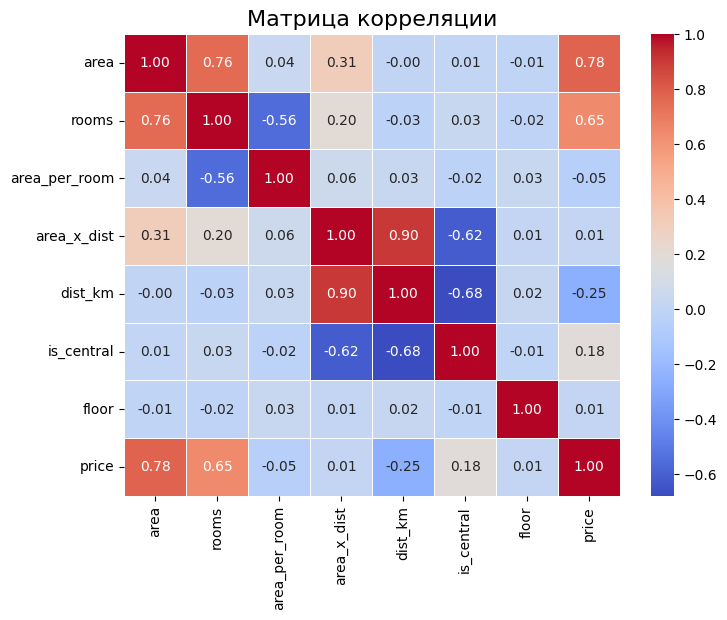

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

check = df[['area', 'rooms', 'area_per_room', 'area_x_dist', 'dist_km', 'is_central', 'floor', 'price']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    check,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5

)
plt.title('Матрица корреляции', fontsize=16)
plt.show()

## Categorical features: one-hot (номинальные) & ordinal (порядковые)

In [21]:
dummies = pd.get_dummies(df[['city', 'condition', ]], dtype=int)
print(f' 2 Columns before, and now: {dummies.shape[1]}')
dummies.head()

 2 Columns before, and now: 8


,city_Київ,city_Львів,city_Одеса,city_Харків,condition_аварійний,condition_житловий,condition_хороший,condition_євроремонт
0,1,0,0,0,0,0,1,0
1,0,0,1,0,0,1,0,0
2,0,0,0,1,1,0,0,0
3,0,1,0,0,0,1,0,0
4,1,0,0,0,0,1,0,0


In [25]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded = ohe.fit_transform(df[['city']])
encoded

print(list(ohe.categories_[0]))

pd.DataFrame(encoded[:5], columns=ohe.get_feature_names_out(['city'])).astype(int)


['Київ', 'Львів', 'Одеса', 'Харків']


,city_Київ,city_Львів,city_Одеса,city_Харків
0,1,0,0,0
1,0,0,1,0
2,0,0,0,1
3,0,1,0,0
4,1,0,0,0


### Ordinal

In [26]:
df['condition'].unique()

array(['хороший', 'житловий', 'аварійний', 'євроремонт'], dtype=object)

In [31]:
from sklearn.preprocessing import OrdinalEncoder

order = [['аварійний', 'житловий', 'хороший', 'євроремонт']]
oe = OrdinalEncoder(categories=order)

apt_demo = apt[['condition']].copy()
apt_demo['condition_code'] = oe.fit_transform(apt[['condition']]).astype(int)

apt_demo.drop_duplicates().sort_values('condition_code')

,condition,condition_code
2,аварійний,0
1,житловий,1
0,хороший,2
12,євроремонт,3


In [32]:
df['condition_code'] = oe.fit_transform(apt[['condition']]).astype(int)
df.head()

,area,rooms,floor,dist_km,city,condition,listing_date,price,area_per_room,area_x_dist,is_central,floor_group,list_month,list_weekday,is_weekend,condition_code
0,81.2,3,20,4.4,Київ,хороший,2024-04-23,260.7,27.1,357.3,0,high,4,1,0,2
1,72.3,3,10,4.0,Одеса,житловий,2025-01-31,216.3,24.1,289.2,0,high,1,4,0,1
2,73.7,4,23,1.2,Харків,аварійний,2024-06-22,179.1,18.4,88.4,1,high,6,5,1,0
3,32.7,1,9,2.8,Львів,житловий,2024-09-11,98.1,32.7,91.6,1,middle,9,2,0,1
4,84.2,3,2,5.3,Київ,житловий,2025-04-10,257.1,28.1,446.3,0,low,4,3,0,1


In [37]:
df.columns

Index(['area', 'rooms', 'floor', 'dist_km', 'city', 'condition', 'listing_date', 'price', 'area_per_room', 'area_x_dist', 'is_central',
       'floor_group', 'list_month', 'list_weekday', 'is_weekend', 'condition_code'],
      dtype='object')

In [43]:
numeric_cols = ['area', 'rooms', 'floor', 'dist_km', 'listing_date', 'area_per_room', 'area_x_dist', 'is_central',
                'list_month', 'list_weekday', 'is_weekend', 'condition_code']

X = pd.concat([
    df[numeric_cols],
    pd.DataFrame(encoded, index = df.index, columns=ohe.get_feature_names_out(['city'])).astype(int)
    # apt_demo['condition_code']
], axis=1)

y = df['price']

x.head()


,area,rooms,floor,dist_km,listing_date,area_per_room,area_x_dist,is_central,list_month,list_weekday,is_weekend,condition_code,city_Київ,city_Львів,city_Одеса,city_Харків
0,81.2,3,20,4.4,2024-04-23,27.1,357.3,0,4,1,0,2,1,0,0,0
1,72.3,3,10,4.0,2025-01-31,24.1,289.2,0,1,4,0,1,0,0,1,0
2,73.7,4,23,1.2,2024-06-22,18.4,88.4,1,6,5,1,0,0,0,0,1
3,32.7,1,9,2.8,2024-09-11,32.7,91.6,1,9,2,0,1,0,1,0,0
4,84.2,3,2,5.3,2025-04-10,28.1,446.3,0,4,3,0,1,1,0,0,0


In [45]:
X.dtypes.value_counts()

,count
int64,9
float64,4
int32,2
datetime64[ns],1


In [46]:
int(X.isna().sum().sum())

0

In [47]:
len(x) == len(y)

True

Поділ: тренувальні/тестувальні
Обрати (LinearRegression) і навчити модель
Передбачення і оцінка

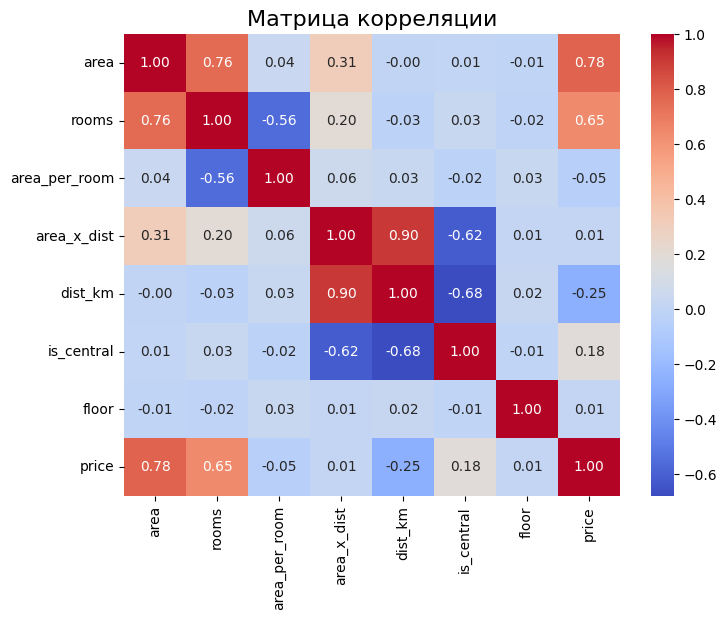